In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle

In [8]:
def build_gru_model(input_shape):

    """
    Xây dựng một mạng GRU cơ bản
    """

    model = Sequential()
    
    # Layer GRU 1
    model.add(GRU(units=64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # Layer GRU 2
    model.add(GRU(units=64, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Layer Mật độ (Dense) cho output
    model.add(Dense(units=1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

In [9]:
print("1. Loading preprocessed data from data_preprocessing notebook...")

with open('../data/preprocessed/preprocessed_data_gru.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']

y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
df_long = data_dict['df_long']

print("Data loaded successfully!")
print(f"Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test: X_test {X_test.shape}, y_test {y_test.shape}") 

1. Loading preprocessed data from data_preprocessing notebook...
Data loaded successfully!
Train: X_train (77462, 96, 6), y_train (77462,)
Val: X_val (17411, 96, 6), y_val (17411,)
Test: X_test (17447, 96, 6), y_test (17447,)


In [10]:
# Dữ liệu GRU/LSTM phải được đem đi scale từ 0 đến 1 thì Neural Network mới hội tụ tốt.
print("2. Đang chuẩn hóa (Scale) đa biến về 0-1...")
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
    
feature_cols = ['Traffic_Volume', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_rush_hour', 'is_night']
    
# Ta copy lại giá trị thật để so sánh sau này nếu cần
df_long['Traffic_Volume_Original'] = df_long['Traffic_Volume']
    
# Fit scaler riêng cho y (cột số 0) để inverse_transform sau này dễ dàng
scaler_y.fit(df_long[['Traffic_Volume']])
    
# Scale tất cả các features đang có
df_long[feature_cols] = scaler_x.fit_transform(df_long[feature_cols])

2. Đang chuẩn hóa (Scale) đa biến về 0-1...


In [11]:
# Cửa sổ trượt (Time Steps = 96 tương đương dữ liệu ngày trước đoán ngày sau)
sequence_length = 96
print(f"3 & 4. Đang tạo Sequences và chẻ Dataset (Time steps = {sequence_length})...")    
print(f"X_train size: {X_train.shape}")
print(f"X_val size: {X_val.shape}")
print(f"X_test size: {X_test.shape}")

3 & 4. Đang tạo Sequences và chẻ Dataset (Time steps = 96)...
X_train size: (77462, 96, 6)
X_val size: (17411, 96, 6)
X_test size: (17447, 96, 6)


In [12]:
print("\n5. Compile và Train GRU...")
# shape cho input là (time_steps, features) cụ thể là (96, 6)
model = build_gru_model((X_train.shape[1], X_train.shape[2]))
model.summary()
    
# Early stop để chống overfit
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
# Huấn luyện (giới hạn ở 10 epochs để debug nhanh, có thể tăng lên sau)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


5. Compile và Train GRU...


c:\Users\Admin\Documents\COS30019-Group-7-Assignment2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 96, 64)         │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,849 (151.75 KB)

 Trainable params: 38,849 (151.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 61s 48ms/step - loss: 0.0031 - val_loss: 9.7804e-04
Epoch 2/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 78s 64ms/step - loss: 0.0015 - val_loss: 8.9028e-04
Epoch 3/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - loss: 0.0013 - val_loss: 8.2453e-04
Epoch 4/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 89s 73ms/step - loss: 0.0012 - val_loss: 8.4792e-04
Epoch 5/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 94s 77ms/step - loss: 0.0012 - val_loss: 7.6122e-04
Epoch 6/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 89s 73ms/step - loss: 0.0011 - val_loss: 8.3568e-04
Epoch 7/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 91s 75ms/step - loss: 0.0011 - val_loss: 7.5512e-04
Epoch 8/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 92s 76ms/step - loss: 0.0011 - val_loss: 8.2036e-04
Epoch 9/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 91s 75ms/step - loss: 0.0010 - val_loss: 7.2075e-04
Epoch 10/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 91s 75ms/step - loss: 0.0010 - val_loss: 7.5042e-04



6. Đang vẽ biẻu đồ lịch sử Huấn Luyện (Loss)....


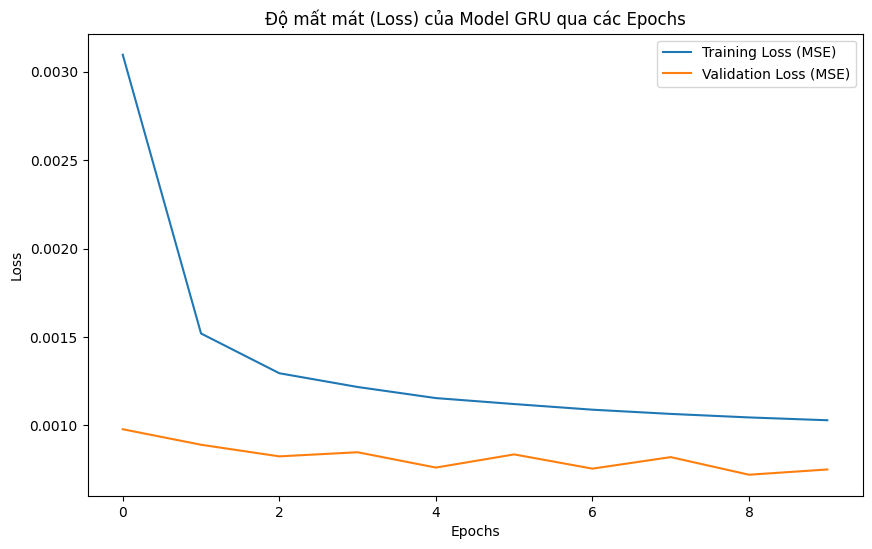

In [13]:
print("\n6. Đang vẽ biẻu đồ lịch sử Huấn Luyện (Loss)....")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Độ mất mát (Loss) của Model GRU qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
    


7. Đánh giá Model thực trên tập Test Set...
546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 8.1642e-04
Test Loss (MSE - scaled format): 0.0008164216415025294
546/546 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step


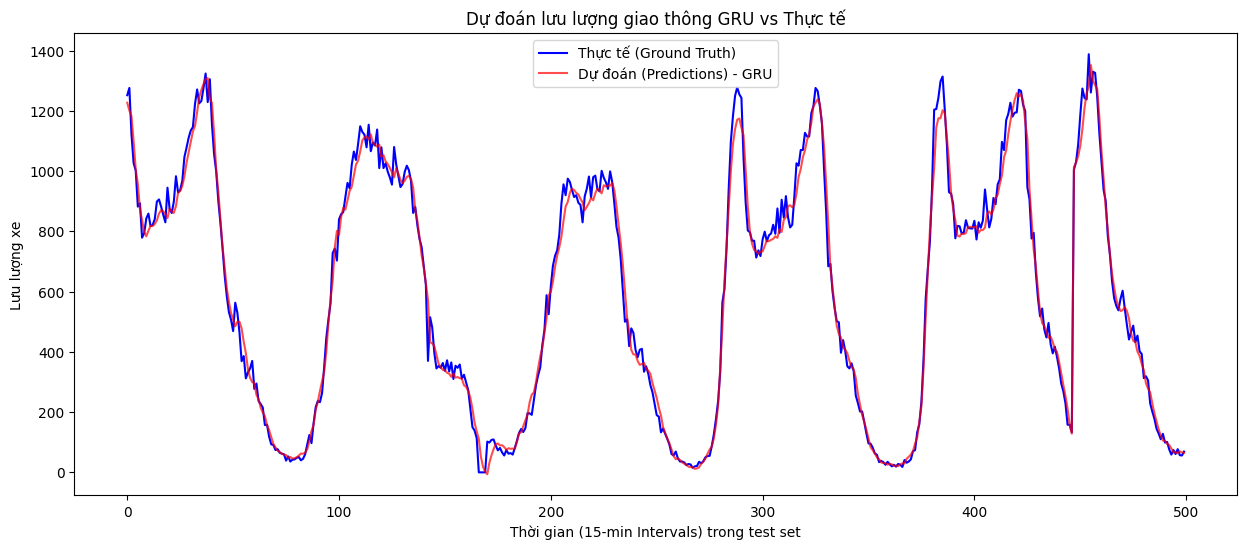

In [14]:
print("\n7. Đánh giá Model thực trên tập Test Set...")
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE - scaled format): {test_loss}")
    
# Dự đoán thử một đoạn trên Test
predictions = model.predict(X_test)
    
# Bấm ngược lại scale ra số thật
predictions_denorm = scaler_y.inverse_transform(predictions)
y_test_denorm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    
# Vẽ vài khung so sánh kết quả prediction vs thực tế
plt.figure(figsize=(15, 6))
# Hiện 500 điểm dữ liệu đầu trong Test để dễ nhìn
plt.plot(y_test_denorm[:500], label='Thực tế (Ground Truth)', color='blue')
plt.plot(predictions_denorm[:500], label='Dự đoán (Predictions) - GRU', color='red', alpha=0.7)
plt.title('Dự đoán lưu lượng giao thông GRU vs Thực tế')
plt.xlabel('Thời gian (15-min Intervals) trong test set')
plt.ylabel('Lưu lượng xe')
plt.legend()
plt.show()

In [15]:
model.save('../models/gru/gru_model.keras')
print("GRU model saved successfully!")

GRU model saved successfully!
